# Clase 2: Modelos Supervisados: Regresión y Clasificación
---

<img src="../img/sergio_portrait_square.png" alt="Sergio Benito" align="right" width="100">

- **Autor:** Sergio Benito Martín
- **Contacto:** pontia@sergiobenito.com
- **Última actualización:** 19/04/2026

Chuleta (cheatsheet) Algoritmos:

| Algoritmo               | Tipología                 | Clase en sklearn                         | Hiperparámetros clave                         | ¿Requiere escalado?             | ¿Cuándo usarlo?                                    | Ventajas                              | Inconvenientes                                |
| ----------------------- | ------------------------- | ---------------------------------------- | --------------------------------------------- | --------------------------------------- | -------------------------------------------------- | ------------------------------------- | --------------------------------------------- |
| **Regresión Lineal**    | Lineal                    | `LinearRegression`                       | `fit_intercept`, `normalize`                  | Escalado opcional                       | Relación lineal, datos sencillos                   | Muy interpretable, rápido             | Supone linealidad, sensible a outliers        |
| **Ridge Regression**    | Lineal                    | `Ridge`                                  | `alpha`, `fit_intercept`                      | Escalado recomendable                   | Multicolinealidad, regularización suave            | Reduce sobreajuste, interpretable     | No elimina variables irrelevantes             |
| **Lasso Regression**    | Lineal                    | `Lasso`                                  | `alpha`, `max_iter`                           | Escalado recomendable                   | Muchas variables, selección automática             | Selección de variables, regulariza    | Puede eliminar variables importantes          |
| **Regresión Logística** | Lineal                    | `LogisticRegression`                     | `C`, `penalty`, `solver`                      | Escalado recomendable, codificar cat.   | Clasificación binaria o multiclase sencilla        | Interpretable, rápida                 | No capta relaciones no lineales               |
| **k-NN**                | Vecinos                   | `KNeighborsClassifier`/`Regressor`       | `n_neighbors`, `weights`                      | Escalado imprescindible                 | Datos pequeños, relación de similitud              | Fácil de entender, sin entrenamiento  | Costoso en predicción, sensible a la escala   |
| **Árbol de Decisión**   | Árboles                   | `DecisionTreeClassifier`/`Regressor`     | `max_depth`, `min_samples_split`              | Codificar categóricas si no son num.    | Interpretabilidad, relaciones complejas            | Fácil de visualizar, variables mixtas | Sobreajuste si no se poda, sensible a cambios |
| **Random Forest**       | Ensamble (árboles)        | `RandomForestClassifier`/`Regressor`     | `n_estimators`, `max_depth`                   | Codificar categóricas si no son num.    | Datos complejos, evitar sobreajuste de árbol único | Preciso, robusto a outliers y ruido   | Menos interpretable, más lento                |
| **SVM**                 | Kernel (lineal/no lineal) | `SVC`/`SVR`                              | `C`, `kernel`, `gamma`                        | Escalado imprescindible                 | Separación clara, tamaño medio, numéricas          | Preciso, robusto al sobreajuste       | Difícil de ajustar, lento en grandes datos    |
| **Gradient Boosting**   | Ensamble (árboles)        | `GradientBoostingClassifier`/`Regressor` | `n_estimators`, `learning_rate`, `max_depth`  | Codificar categóricas si no son num.    | Máxima precisión, relaciones complejas             | Muy preciso, relaciones complejas     | Requiere ajuste, más lento                    |
| **XGBoost**             | Ensamble (árboles)        | `XGBClassifier`/`XGBRegressor`           | `n_estimators`, `learning_rate`, `max_depth`  | Codificar categóricas si no son num.    | Datos tabulares, alta precisión                    | Muy eficiente y preciso               | Ajuste complejo, puede sobreajustar           |
| **LightGBM**            | Ensamble (árboles)        | `LGBMClassifier`/`LGBMRegressor`         | `num_leaves`, `learning_rate`, `n_estimators` | Acepta categóricas (mejor codificarlas) | Grandes volúmenes de datos, rapidez                | Rápido, eficiente, buena precisión    | Puede sobreajustar, hiperparámetros complejos |

### Para profundizar más 🤓

Comparación modelos de clasificación:
<center><img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_classifier_comparison_001.png" alt="Comparativa modelos de clasificación" width=1000/></center>
<center><a src="https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html">Fuente: Sklearn - Classifier comparison</a></center>

Cheatsheet comparativa de las dos técnicas de escalado típicas:
| Característica          | `StandardScaler`                               | `MinMaxScaler`                                   |
|------------------------|----------------------------------------------|------------------------------------------------|
| ¿Qué hace?             | Escala los datos a media 0 y varianza 1      | Escala los datos al rango [0, 1] (por defecto) |
| Fórmula                | z = (x - media) / desviación estándar        | x' = (x - min) / (max - min)                   |
| Cuándo usarlo          | Datos ~ normales<br>Modelos lineales<br>SVM, k-NN, Regresión, Redes neuronales<br>No conoces los límites de los datos | Datos NO normales<br>Valores en un rango conocido<br>Imágenes, redes neuronales (sigmoide, ReLU)<br>Visualización |
| Ventajas               | Menos sensible a valores extremos (que MinMax)<br>Funciona bien en la mayoría de modelos | Mantiene proporciones originales<br>Útil si el modelo requiere entradas entre 0 y 1 |
| Inconvenientes         | Si hay muchos outliers, mejor usar RobustScaler | Muy sensible a outliers (pueden distorsionar el rango) |
| Modelos recomendados   | Regresión, SVM, k-NN, Redes neuronales       | Redes neuronales, k-NN, modelos sensibles a la magnitud absoluta |
| Ejemplo sklearn        | `sklearn.preprocessing.StandardScaler()`                           | `sklearn.preprocessing.MinMaxScaler()`                               |

## 0. Configuración del Notebook
Importaremos todas las librerías y funciones que vemos relevantes para el notebook que vamos a crear. Lo ideal sería tener todas las importaciones juntas, de tal manera que se puedan controlar de manera sencilla.

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union
from xgboost import XGBClassifier, XGBRegressor

### Definición de constantes

In [2]:
PATH_DIRECTORIO_DATOS = "../data"

In [3]:
PATH_DATASET_ADVERTISING = f"{PATH_DIRECTORIO_DATOS}/advertising.csv"
PATH_DATASET_CALORIES = f"{PATH_DIRECTORIO_DATOS}/calories.csv"
PATH_DATASET_CALORIES_LITE = f"{PATH_DIRECTORIO_DATOS}/calories_time_reduc.csv"
PATH_DATASET_CALORIES_TIME = f"{PATH_DIRECTORIO_DATOS}/calories_time.csv"
PATH_DATASET_HEART = f"{PATH_DIRECTORIO_DATOS}/heart_disease.csv"
PATH_DATASET_BOSTON = f"{PATH_DIRECTORIO_DATOS}/housing_boston.csv"
PATH_DATASET_TWEETS = f"{PATH_DIRECTORIO_DATOS}/nlp_tweets.csv"

### Definición de funciones

In [4]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

In [5]:
def plot_knn_decision_boundary(
    model: object, 
    X: Union[np.ndarray, pd.DataFrame], 
    y: Union[np.ndarray, pd.Series], 
    feature1_idx: Union[int, str] = 0, 
    feature2_idx: Union[int, str] = 1, 
    feature_names: Optional[List[str]] = None, 
    class_names: Optional[List[str]] = None, 
    mesh_step_size: float = 0.02, 
    plot_title: str = "KNN Decision Boundary",
    figsize: Tuple[int, int] = (10, 8)
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Visualiza el límite de decisión (decision boundary) para un modelo KNN con 2 variables seleccionadas.
    
    Args:
        model: Modelo KNN ya entrenado con métodos predict y predict_proba
        X: Array o DataFrame con todas las características (features)
        y: Array o Series con las etiquetas (target)
        feature1_idx: Índice o nombre de la primera característica a visualizar
        feature2_idx: Índice o nombre de la segunda característica a visualizar
        feature_names: Lista con los nombres de las características (opcional)
        class_names: Lista con los nombres de las clases (opcional)
        mesh_step_size: Tamaño del paso para crear la malla de visualización
        plot_title: Título del gráfico
        figsize: Tamaño de la figura como tupla (ancho, alto)
        
    Returns:
        Tuple[plt.Figure, plt.Axes]: Objetos de la figura y eje para posibles personalizaciones adicionales
    """
    
    # Convertir DataFrame a NumPy array si es necesario
    if hasattr(X, 'iloc'):
        # Si se pasan nombres de características en lugar de índices
        if isinstance(feature1_idx, str):
            feature1_idx = X.columns.get_loc(feature1_idx)
        if isinstance(feature2_idx, str):
            feature2_idx = X.columns.get_loc(feature2_idx)
        
        # Extraer los nombres de las características si no se proporcionaron
        if feature_names is None and hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
            
        X = X.values
        
    if hasattr(y, 'values'):
        y = y.values
    
    # Extraer las dos características a visualizar
    X_2d = X[:, [feature1_idx, feature2_idx]]
    
    # Crear figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Definir colores para las clases y regiones
    n_classes = len(np.unique(y))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Definir mapas de color para el scatter plot y para las regiones
    cmap_bold = ListedColormap(colors[:n_classes])
    cmap_light = ListedColormap([f'#{color[1:]}33' for color in colors[:n_classes]])
    
    # Determinar límites para el gráfico
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    
    # Crear una malla para visualizar el límite de decisión
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    
    # Asegurar que el modelo tiene método predict
    if hasattr(model, 'predict'):
        # Preparar los datos de la malla para predecir
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Si el modelo fue entrenado con más de 2 características, necesitamos manejar esto
        if X.shape[1] > 2:
            # Crear datos dummy para las características no visualizadas
            X_mean = np.mean(X, axis=0)
            mesh_full = np.zeros((mesh_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature1_idx:
                    mesh_full[:, i] = mesh_points[:, 0]
                elif i == feature2_idx:
                    mesh_full[:, i] = mesh_points[:, 1]
                else:
                    # Usar la media para las otras características
                    mesh_full[:, i] = X_mean[i]
            
            # Predecir clases para cada punto de la malla
            Z = model.predict(mesh_full)
        else:
            # Si solo hay 2 características, predecir directamente
            Z = model.predict(mesh_points)
        
        # Dar forma a los resultados de vuelta a la forma de la malla
        Z = Z.reshape(xx.shape)
        
        # Trazar el límite de decisión
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Trazar los puntos de datos reales
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_bold, 
                         edgecolor='k', s=50, alpha=0.8)
    
    # Configurar etiquetas y título
    if feature_names is not None:
        ax.set_xlabel(feature_names[feature1_idx])
        ax.set_ylabel(feature_names[feature2_idx])
    else:
        ax.set_xlabel(f'Feature {feature1_idx}')
        ax.set_ylabel(f'Feature {feature2_idx}')
    
    ax.set_title(plot_title)
    
    # Añadir leyenda si hay nombres de clases
    if class_names is not None:
        legend1 = ax.legend(scatter.legend_elements()[0], 
                            class_names,
                            loc="upper right", 
                            title="Classes")
        ax.add_artist(legend1)
    
    # Añadir grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [6]:
def plot_svc_decision_boundary(
    model: object, 
    X: Union[np.ndarray, pd.DataFrame], 
    y: Union[np.ndarray, pd.Series], 
    feature1_idx: Union[int, str] = 0, 
    feature2_idx: Union[int, str] = 1, 
    feature_names: Optional[List[str]] = None, 
    class_names: Optional[List[str]] = None, 
    mesh_step_size: float = 0.02, 
    plot_title: str = "SVC Decision Boundary",
    figsize: Tuple[int, int] = (10, 8)
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Visualiza el hiperplano de decisión (decision boundary) para un modelo SVC con 2 variables seleccionadas.
    
    Args:
        model: Modelo SVC ya entrenado con método predict
        X: Array o DataFrame con todas las características (features)
        y: Array o Series con las etiquetas (target)
        feature1_idx: Índice o nombre de la primera característica a visualizar
        feature2_idx: Índice o nombre de la segunda característica a visualizar
        feature_names: Lista con los nombres de las características (opcional)
        class_names: Lista con los nombres de las clases (opcional)
        mesh_step_size: Tamaño del paso para crear la malla de visualización
        plot_title: Título del gráfico
        figsize: Tamaño de la figura como tupla (ancho, alto)
        
    Returns:
        Tuple[plt.Figure, plt.Axes]: Objetos de la figura y eje para posibles personalizaciones adicionales
    """
    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Convertir DataFrame a NumPy array si es necesario
    if hasattr(X, 'iloc'):
        # Si se pasan nombres de características en lugar de índices
        if isinstance(feature1_idx, str):
            feature1_idx = X.columns.get_loc(feature1_idx)
        if isinstance(feature2_idx, str):
            feature2_idx = X.columns.get_loc(feature2_idx)
        
        # Extraer los nombres de las características si no se proporcionaron
        if feature_names is None and hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
            
        X = X.values
        
    if hasattr(y, 'values'):
        y = y.values
    
    # Extraer las dos características a visualizar
    X_2d = X[:, [feature1_idx, feature2_idx]]
    
    # Crear figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Definir colores para las clases y regiones
    n_classes = len(np.unique(y))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Definir mapas de color para el scatter plot y para las regiones
    cmap_bold = ListedColormap(colors[:n_classes])
    cmap_light = ListedColormap([f'#{color[1:]}33' for color in colors[:n_classes]])
    
    # Determinar límites para el gráfico
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    
    # Crear una malla para visualizar el límite de decisión
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    
    # Asegurar que el modelo tiene método predict
    if hasattr(model, 'predict'):
        # Preparar los datos de la malla para predecir
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Si el modelo fue entrenado con más de 2 características, necesitamos manejar esto
        if X.shape[1] > 2:
            # Crear datos dummy para las características no visualizadas
            X_mean = np.mean(X, axis=0)
            mesh_full = np.zeros((mesh_points.shape[0], X.shape[1]))
            for i in range(X.shape[1]):
                if i == feature1_idx:
                    mesh_full[:, i] = mesh_points[:, 0]
                elif i == feature2_idx:
                    mesh_full[:, i] = mesh_points[:, 1]
                else:
                    # Usar la media para las otras características
                    mesh_full[:, i] = X_mean[i]
            
            # Predecir clases para cada punto de la malla
            Z = model.predict(mesh_full)
        else:
            # Si solo hay 2 características, predecir directamente
            Z = model.predict(mesh_points)
        
        # Dar forma a los resultados de vuelta a la forma de la malla
        Z = Z.reshape(xx.shape)
        
        # Trazar el límite de decisión
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Trazar los puntos de datos reales
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_bold, 
                         edgecolor='k', s=50, alpha=0.8)
    
    # Configurar etiquetas y título
    if feature_names is not None:
        ax.set_xlabel(feature_names[feature1_idx])
        ax.set_ylabel(feature_names[feature2_idx])
    else:
        ax.set_xlabel(f'Feature {feature1_idx}')
        ax.set_ylabel(f'Feature {feature2_idx}')
    
    ax.set_title(plot_title)
    
    # Añadir leyenda si hay nombres de clases
    if class_names is not None:
        legend1 = ax.legend(scatter.legend_elements()[0], 
                            class_names,
                            loc="upper right", 
                            title="Classes")
        ax.add_artist(legend1)
    
    # Dibujar vectores de soporte si están disponibles
    if hasattr(model, 'support_vectors_'):
        # Encontrar los vectores de soporte para las 2 dimensiones que estamos visualizando
        support_vectors = model.support_vectors_
        
        # Si tenemos más de 2 dimensiones, filtrar solo las 2 que estamos visualizando
        if support_vectors.shape[1] > 2:
            support_vectors = support_vectors[:, [feature1_idx, feature2_idx]]
        
        # Dibujar los vectores de soporte
        ax.scatter(support_vectors[:, 0], support_vectors[:, 1], 
                   s=100, linewidth=1, facecolors='none', edgecolors='k',
                   label='Support Vectors')
        ax.legend()
    
    # Añadir grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

## 1. Creación de un modelo de regresión logística para clasificación
Una vez ya conocemos cómo se implementa un modelo de regresión lineal para una regresión, haremos lo mismo con el algoritmo más sencillo para el caso de la clasificación, la regresión logística.

### Lectura de datos
Utilizaremos el dataset de Iris, que nos permite clasificar flores en función a las dimensiones de ancho y largo de cada uno de sus pétalos. Este dataset tiene las siguientes variables:
- ***class***: Clase de la flor (Iris-versicolor, Iris-setosa)
- ***sepal_length***: El "largo" del Sepalo
- ***sepal_width***: El "ancho" del Sepalo
- ***petal_length***: El "largo" del Pétalo
- ***petal_width***: El "ancho" del Pétalo

<center><img src="https://miro.medium.com/max/3500/1*f6KbPXwksAliMIsibFyGJw.png" alt="Iris flores" width="700"/></center>

Gracias `sklearn` es posible cargar datasets directamente de esta librería desde su módulo: `datasets`. Para ello, importar la siguiente línea de código:

```python
from sklearn.datasets import load_iris
```

In [7]:
# Cargamos Iris desde la función de sklearn
data_iris = load_iris(as_frame=True, return_X_y=False)

In [8]:
data_iris

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 'target': 0     

In [9]:
# Mostramos las keys
data_iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [10]:
# Añadimos a un dataframe todas las variables independientes
df_iris = data_iris['data']
list_columnas_independientes = df_iris.columns

In [11]:
target_column = 'target'
data_iris[target_column]

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [12]:
# Añadimos la columna que representa las clases a predecir
target_column = 'target'
df_iris[target_column] = data_iris[target_column]

In [13]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
data_iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [15]:
# Cargamos también los nombres de las flores (clases) en este caso
list_nombres_clases = data_iris.target_names
list_nombres_clases

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Comprobación y preprocesamiento de datos
Veremos cuáles son los datos que tenemos en el Dataframe, si los tipos asignados tienen sentido, descriptivo estadístico de las columnas, etc

In [16]:
# Mostrar las primeras filas del DataFrame
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
# Mostrar las dimensiones del DataFrame
df_iris.shape

(150, 5)

In [18]:
# Mostrar información del DataFrame
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [19]:
# Cambiamos el formato de la columna target para convertirse en str
df_iris[target_column] = df_iris[target_column].astype(str)

In [20]:
# Volvemos a mostrar los tipos del DataFrame
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [21]:
# Eliminamos el "(cm)" del nombre de las columnas para simplificarlo así como reducir los espacios
df_iris.columns = df_iris.columns.str.replace(" (cm)", "")
df_iris.columns = df_iris.columns.str.replace(" ", "_")

In [22]:
df_iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target'], dtype='object')

In [23]:
list_nombres_clases

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
# Reemplazamos los valores numéricos de la columna target por los nombres de las clases usando la variable `list_nombres_clases`
df_iris[target_column] = df_iris[target_column].replace({
    '0' : list_nombres_clases[0],
    '1' : list_nombres_clases[1],
    '2' : list_nombres_clases[2]
})

In [25]:
# Aquí una forma más avanzada de obtener el mismo resultado usando un list comprehension


In [26]:
# Descripción estadística de las columnas numéricas
df_iris.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [27]:
# Sin embargo, también se pueden ver los estadísticos de las columnas categóricas
df_iris.describe(include='object').transpose()

,count,unique,top,freq
target,150,3,setosa,50


In [28]:
# Obtenemos las frecuencias absolutas de la columna target
df_iris[target_column].value_counts()

target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [29]:
# Y añadiendo el parámetro `normalize=True` obtenemos las frecuencias relativas
df_iris[target_column].value_counts(normalize=True)

target
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

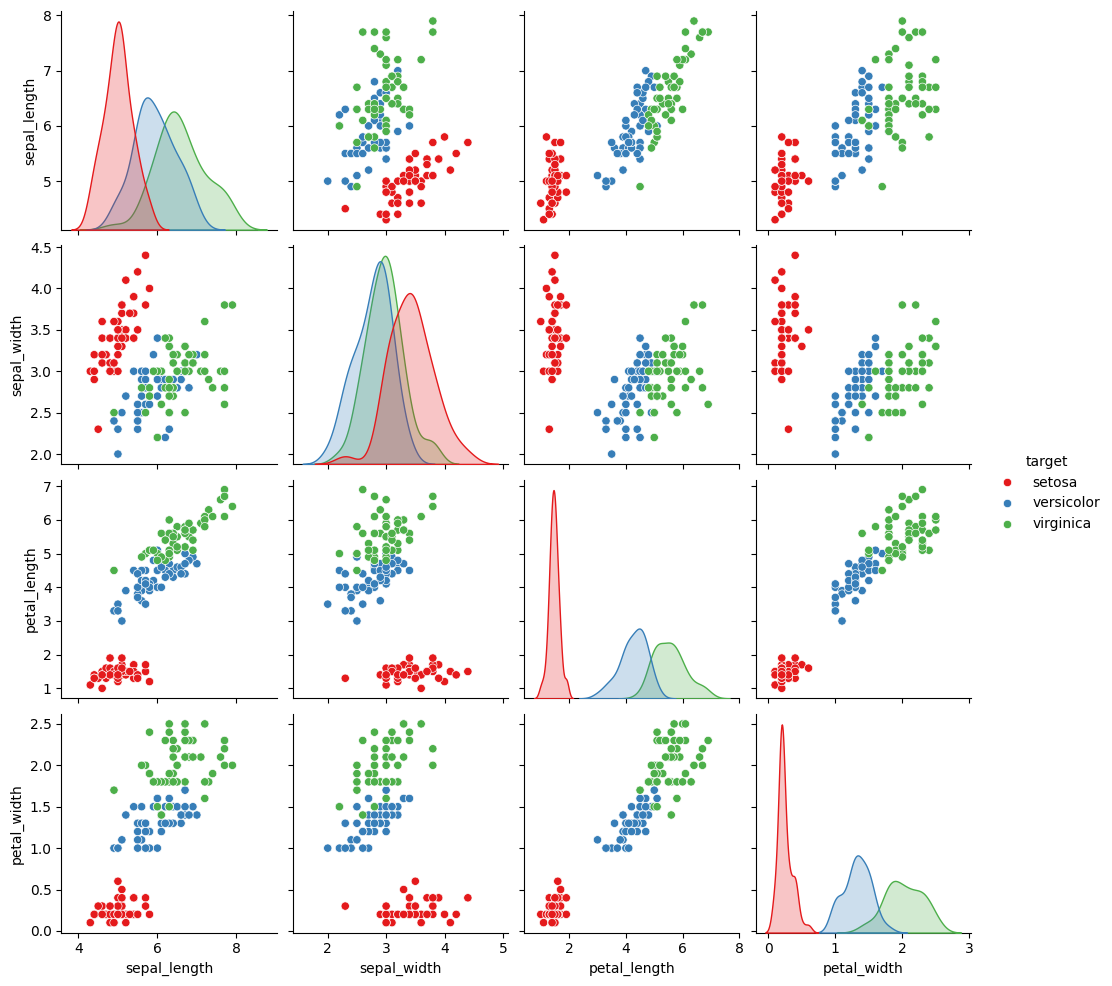

In [30]:
# Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase
sns.pairplot(df_iris, hue=target_column, palette='Set1')

### Creación del modelo
+ En este caso utilizaremos las 4 variables que se utilizan para medir los pétalos y sépalos de cada flor con el objetivo de predecir si es setosa, versicolor o virgínica
+ El paradigma será similar al de la regresión lineal pero en este caso utilizaremos la logística que se ubica en el mismo módulo de sklearn de `linear_models`

```python
from sklearn.linear_model import LogisticRegression
```

In [31]:
df_iris.drop(columns=target_column).columns.to_list()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [32]:
# Seleccionamos las columnas independientes
list_columnas_independientes = df_iris.drop(columns=target_column).columns.to_list()
list_columnas_independientes

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [33]:
# Preparación de los datos para el modelo de regresión logística
X = df_iris[list_columnas_independientes]
y = df_iris[target_column]

In [34]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Creación del modelo de regresión lineal
modelo_rl = LogisticRegression(max_iter=200, random_state=42)
modelo_rl.fit(X_train, y_train)

LogisticRegression(max_iter=200, random_state=42)

In [36]:
# Obtenemos la predicción del modelo
y_pred = modelo_rl.predict(X_test)

### Evaluación del modelo
Evaluaremos el modelo utilizando el accuracy (exactitud) y por otro lado veremos la matriz de confusión:
+ Accuracy: representa el porcentaje de aciertos respecto al total de las predicciones
+ Matriz de confusión: muestra de una manera visualuna tabla que compara las predicciones de un modelo respecto con los valores reales, verdaderos positivos (true positive) y verdaderos falsos (true false).

La fórmula del accuracy es la siguiente:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
Donde:
  + TP = Verdaderos Positivos (True Positives)
  + TN = Verdaderos Negativos (True Negatives)
  + FP = Falsos Positivos (False Positives)
  + FN = Falsos Negativos (False Negatives)

Para ello será necesario importar las siguientes funciones:

```python
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
```

In [37]:
# Ejemplo accuracy con pseudo-codigo:
# accuracy = ok_setosa + ok_versicolor + ok_virginica / (ok_setosa + ok_versicolor + ok_virginica + no_setosa + no_versicolor + no_virginica)

In [38]:
# Evaluamos el modelo usando el accuracy (exactitud)
acc = accuracy_score(y_test, y_pred)
print(acc)

1.0


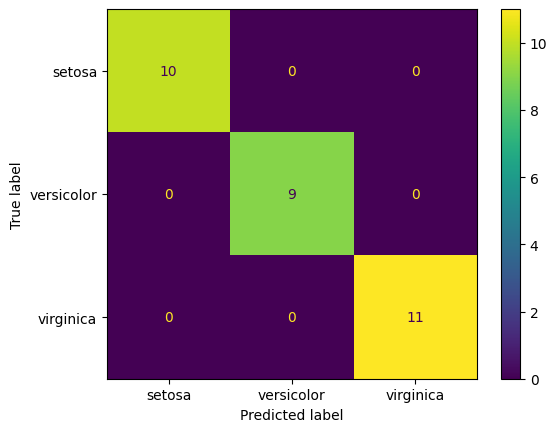

In [39]:
# Generamos una matriz de confusión que permitirá ver cuántas son las predicciones correctas y cuántas incorrectas
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()

## 2. Regresión logística para clasificación binaria
Ahora veremos el caso de una regresión logística pero en este caso aplicándolo para un problma de clasificación binaria (sólo 2 clases). Donde utilizaremos otro dataset común llamado `heart_disease`, lo leeremos directamente del directorio `./data/heart_disease.csv`.

| Variable | Descripción | Tipo |
| -------- | ----------- | ---- |
| age | Edad del paciente | Numérico |
| sex | Sexo (1 = hombre, 0 = mujer) | Binario |
| cp | Tipo de dolor en el pecho (0-3) | Categórico |
| trestbps | Presión arterial en reposo | Numérico |
| chol | Colesterol sérico (mg/dl) | Numérico |
| fbs | Glucemia en ayunas (>120 mg/dl) (1 = sí) | Binario |
| restecg | Resultados electrocardiográficos en reposo | Categórico |
| thalach | Frecuencia cardíaca máxima alcanzada | Numérico |
| exang | Angina inducida por ejercicio (1 = sí) | Binario |
| oldpeak | Depresión del ST inducida por ejercicio | Numérico |
| slope | Pendiente del segmento ST en esfuerzo | Categórico |
| ca | Número de vasos principales (0-3) | Numérico |
| thal | Resultado de la prueba de talio (1,2,3) | Categórico |
| target | Enfermedad cardíaca (1 = Sí, 0 = No) | Binario |

### Lectura de datos

In [40]:
df_heart = pd.read_csv(PATH_DATASET_HEART)

### Preprocesamiento de datos

In [41]:
# Mostramos las primeras filas del DataFrame
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [42]:
# Mostramos las dimensiones del DataFrame
df_heart.shape

(303, 14)

In [43]:
# Mostramos información del DataFrame
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [44]:
# Convertimos las columnas que deberían ser categóricas a tipo string además del target
dict_astype_heart = {
    'cp' : 'str',
    'restecg' : 'str',
    'slope' : 'str',
    'thal' : 'str',
    'target' : 'str'
}

df_heart_preprocessed = df_heart.astype(dict_astype_heart)

In [45]:
df_heart_preprocessed['target']

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: object

In [46]:
# Reemplzamos los valores numéricos de la columna 'target' por los nombres de las clases
dict_target_heart = {
    '0' : 'No enfermedad',
    '1' : 'Enfermedad'
}

df_heart_preprocessed['target'] = df_heart_preprocessed['target'].replace(dict_target_heart)

In [47]:
# Descripción estadística de todas las columnas
df_heart_preprocessed.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,303.0,NaN,NaN,NaN,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,NaN,NaN,NaN,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303,4,0,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,303.0,NaN,NaN,NaN,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,NaN,NaN,NaN,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,NaN,NaN,NaN,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303,3,1,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalach,303.0,NaN,NaN,NaN,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,NaN,NaN,NaN,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,NaN,NaN,NaN,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [48]:
df_heart_preprocessed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
ca,303.0,0.729373,1.022606,0.0,0.0,0.0,1.0,4.0


In [49]:
df_heart_preprocessed.describe(include='object').transpose()

,count,unique,top,freq
cp,303,4,0,143
restecg,303,3,1,152
slope,303,3,2,142
thal,303,4,2,166
target,303,2,Enfermedad,165


In [50]:
# Vemos las frecuencias absolutas de la columna 'target'
df_heart_preprocessed['target'].value_counts()

target
Enfermedad       165
No enfermedad    138
Name: count, dtype: int64

In [51]:
# Ahora vemos las frecuencias relativas
df_heart_preprocessed['target'].value_counts(normalize=True)

target
Enfermedad       0.544554
No enfermedad    0.455446
Name: proportion, dtype: float64

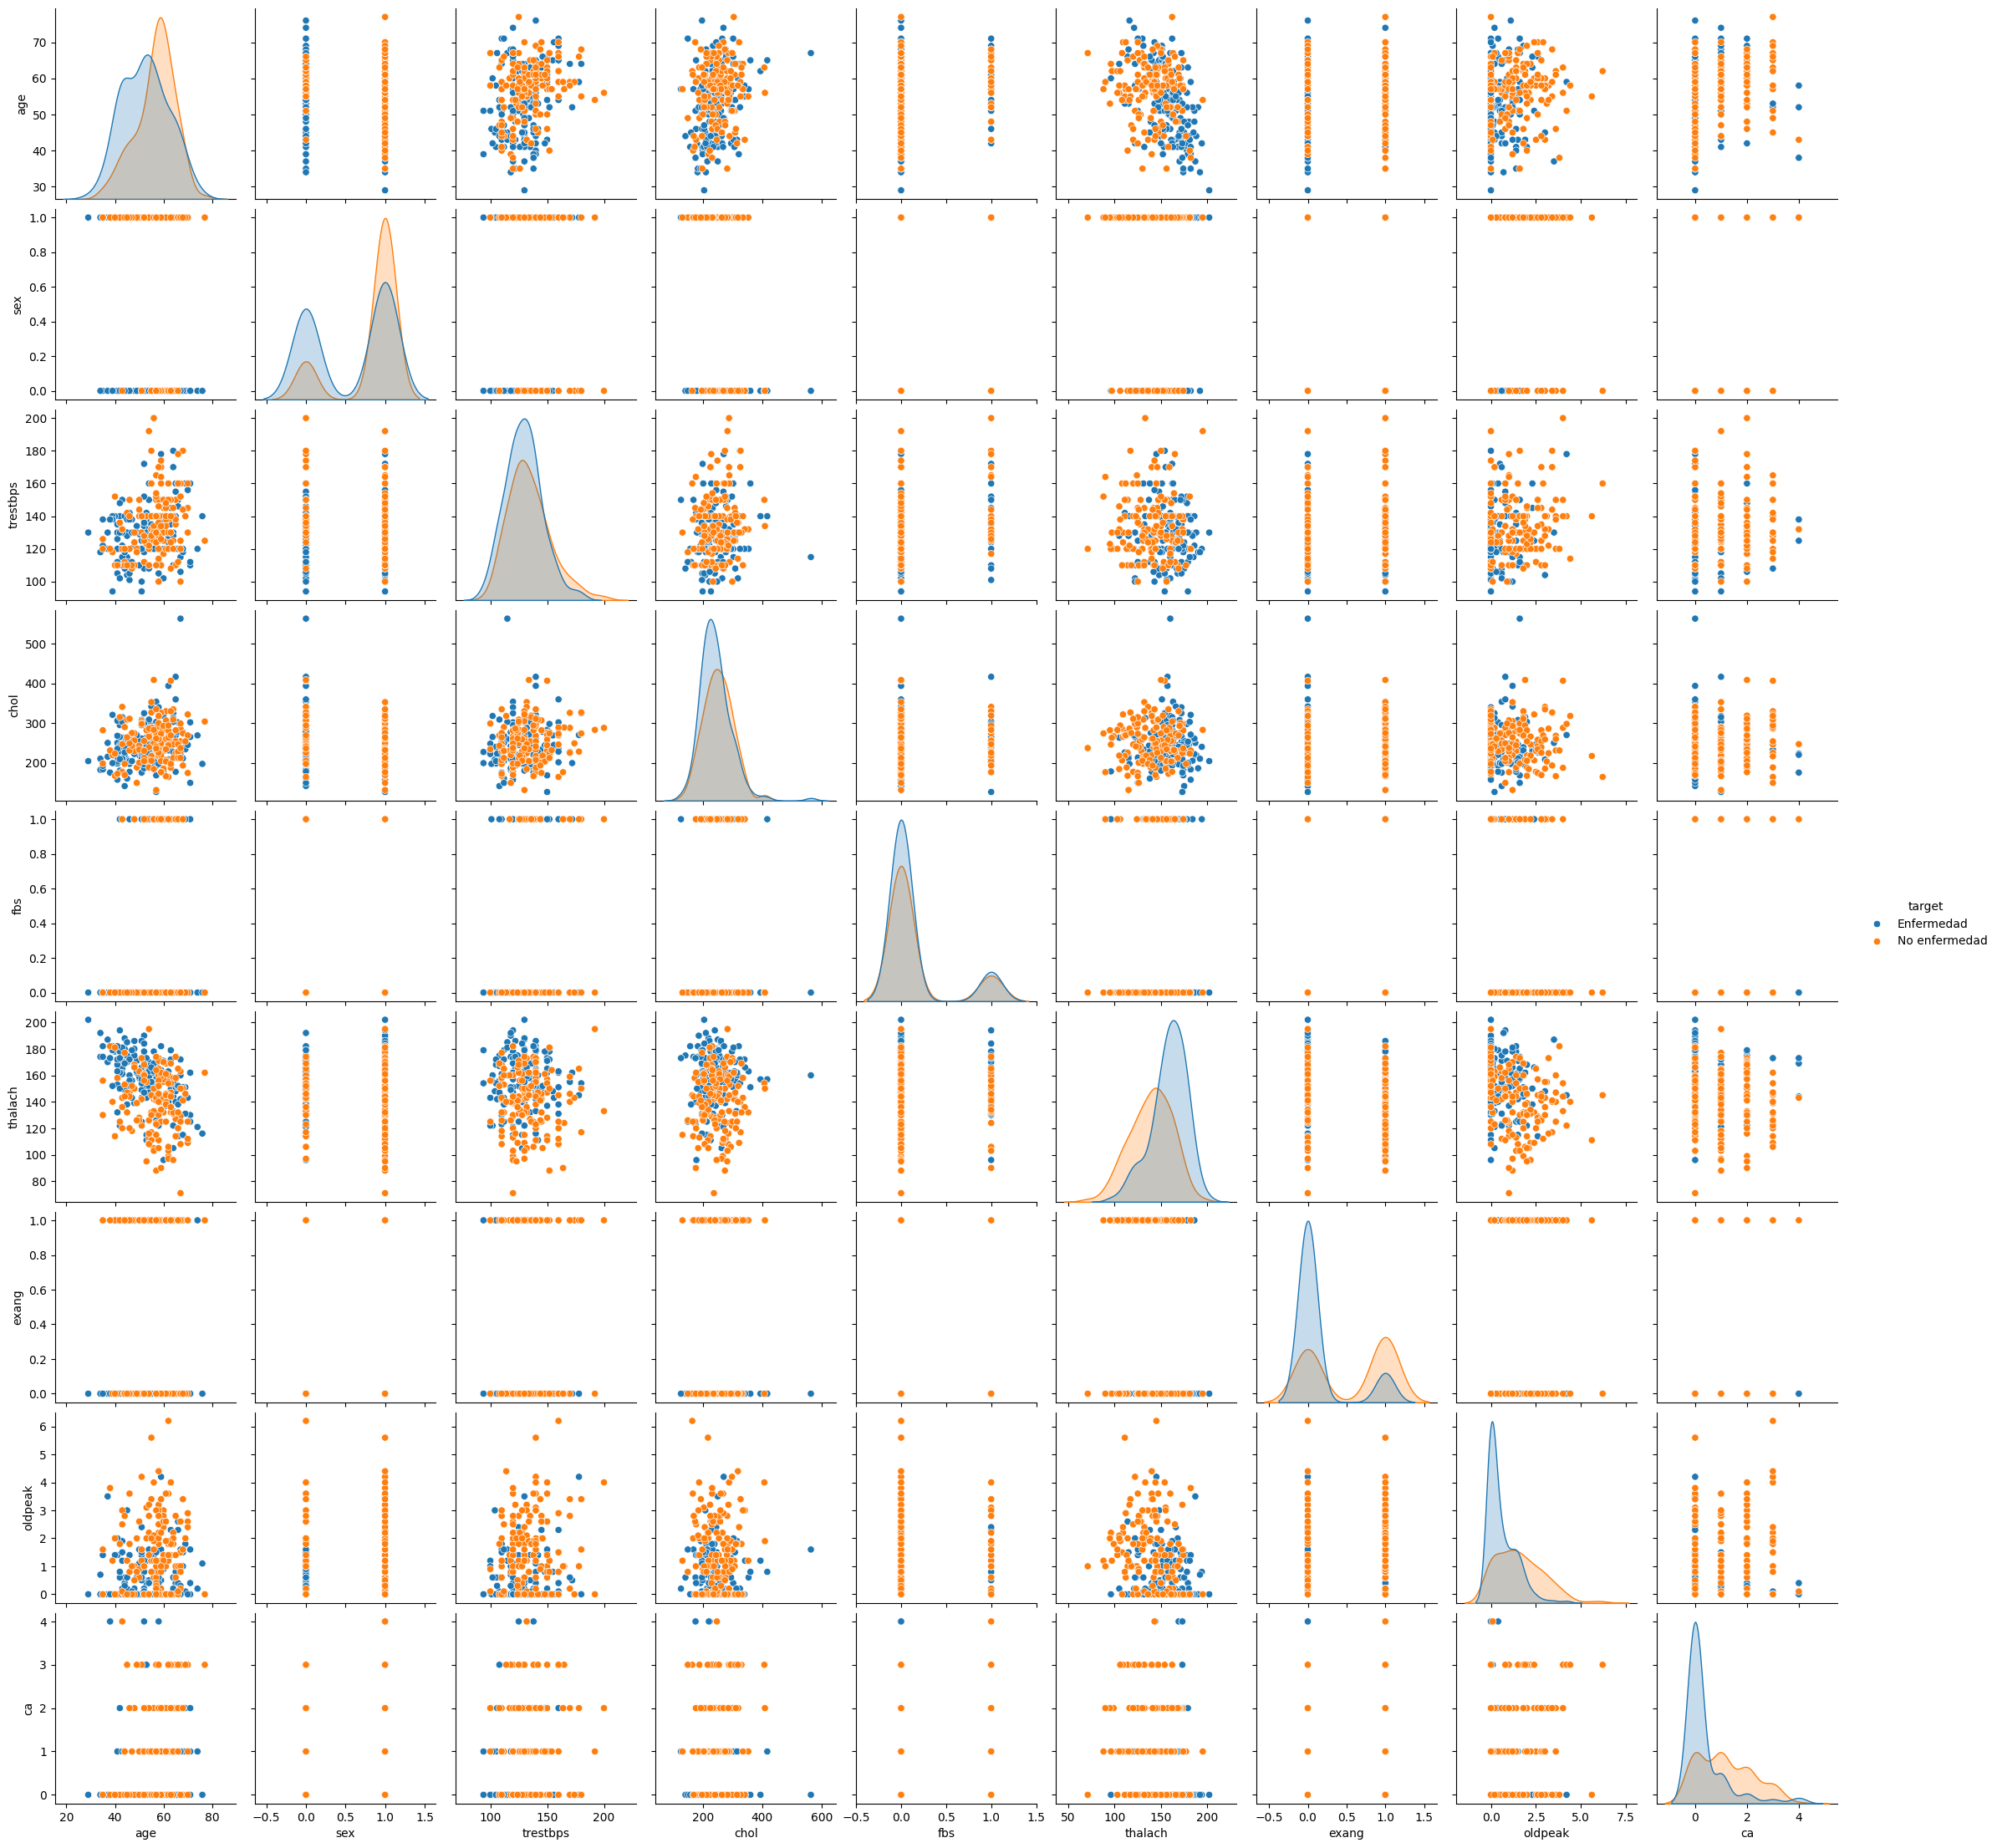

In [52]:
# Hacemos un gráfico de dispersión de las variables numéricas
sns.pairplot(df_heart_preprocessed, hue='target')

### Creación del modelo y ajuste

In [53]:
df_heart_preprocessed['target']

0         Enfermedad
1         Enfermedad
2         Enfermedad
3         Enfermedad
4         Enfermedad
           ...      
298    No enfermedad
299    No enfermedad
300    No enfermedad
301    No enfermedad
302    No enfermedad
Name: target, Length: 303, dtype: object

In [54]:
# Reemplzamos los valores numéricos de la columna 'target' por los nombres de las clases
dict_target_heart = {
    'No enfermedad' : 0,
    'Enfermedad' : 1
}

df_heart_preprocessed['target'] = df_heart_preprocessed['target'].replace(dict_target_heart)

/var/folders/z7/pftfcy9j7f9byrnqq8dfsws00000gq/T/ipykernel_46364/1309193163.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_heart_preprocessed['target'] = df_heart_preprocessed['target'].replace(dict_target_heart)


In [55]:
df_heart_preprocessed['target'].map(dict_target_heart)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
298   NaN
299   NaN
300   NaN
301   NaN
302   NaN
Name: target, Length: 303, dtype: float64

In [56]:
df_heart_preprocessed['target']

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [57]:
# Preparación de los datos para el modelo de regresión logística
# Eliminamos la columna 'target' de las variables independientes
# Y transformamos a numérico la columna target
X_heart = df_heart_preprocessed.drop(columns='target')
y_heart = df_heart_preprocessed['target']

In [58]:
y_heart.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [59]:
# Hacemos un train-test split
X_train, X_test, y_train, y_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

In [60]:
# Verificamos el ratio de las clases para los conjuntos de entrenamiento y prueba
print("Distribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Distribución de clases en el conjunto de entrenamiento:
target
1    0.549587
0    0.450413
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba:
target
1    0.52459
0    0.47541
Name: proportion, dtype: float64


In [61]:
# Hacemos un train-test split utilizando stratify para que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

In [62]:
# Verificamos el ratio de las clases para los conjuntos de entrenamiento y prueba
print("Distribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Distribución de clases en el conjunto de entrenamiento:
target
1    0.545455
0    0.454545
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


In [63]:
X_train.head().info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 19 to 60
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5 non-null      int64  
 1   sex       5 non-null      int64  
 2   cp        5 non-null      object 
 3   trestbps  5 non-null      int64  
 4   chol      5 non-null      int64  
 5   fbs       5 non-null      int64  
 6   restecg   5 non-null      object 
 7   thalach   5 non-null      int64  
 8   exang     5 non-null      int64  
 9   oldpeak   5 non-null      float64
 10  slope     5 non-null      object 
 11  ca        5 non-null      int64  
 12  thal      5 non-null      object 
dtypes: float64(1), int64(8), object(4)
memory usage: 560.0+ bytes


In [64]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

modelo_rl = LogisticRegression(max_iter=500, random_state=42)
modelo_rl_cv = GridSearchCV(modelo_rl, dict_parametros, cv=5, scoring='accuracy')
modelo_rl_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='accuracy')

In [65]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rl_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rl_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 0.1, 'solver': 'liblinear'}
Mejor score obtenido: 83.49%


In [66]:
modelo_rl_cv.best_estimator_

LogisticRegression(C=0.1, max_iter=500, random_state=42, solver='liblinear')

In [67]:
type(modelo_rl)

sklearn.linear_model._logistic.LogisticRegression

In [68]:
type(modelo_rl_cv.best_estimator_)

sklearn.linear_model._logistic.LogisticRegression

In [69]:
# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_rl = LogisticRegression(C=0.1, solver='liblinear', max_iter=500, random_state=42)
modelo_rl.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=500, random_state=42, solver='liblinear')

### Evaluación del modelo
Dado que el caso de uso podría tener un impacto muy relevante, además de que las clases no están balanceadas, será de mayor interés evaluar otras métricas como:
+ **Precisión**: cuántas predicciones de la clase positiva son correctas.
$$\text{Precision} = \frac{TP}{TP + FP}$$

+ **Recall**: cuánta es la cobertura de acierto sobre todas las observaciones de la clase positiva.
$$\text{Recall} = \frac{TP}{TP + FN}$$

+ **F1-Score**: media armónica entre la precisión y el recall, hace un balance entre ambas métricas.
$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

+ **Curva ROC**: compara la tasa de verdaderos positivos (TPR) frente a la de falsos positivos (FPR) para distintos umbrales de decisión.
  + **AUC (Area Under Curve)**: mide el área bajo la curva ROC (de 0.5 a 1). Un modelo perfecto tiene AUC=1. Un modelo aleatorio tiene AUC=0.5.

Será necesario importar las siguientes funciones:
```python
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
```

In [70]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rl.predict(X_test)

In [71]:
# Verificamos las clases del modelo
print(f"Clases modelo: {modelo_rl.classes_}")

Clases modelo: [0 1]


In [72]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
285,46,1,0,140,311,0,1,120,1,1.8,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,58,0,3,150,283,1,0,162,0,1.0,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
224,54,1,0,110,239,0,1,126,1,2.8,1,1,3
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3


In [73]:
pd.DataFrame(X_test.loc[197])

,197
age,67
sex,1
cp,0
trestbps,125
chol,254
fbs,1
restecg,1
thalach,163
exang,0
oldpeak,0.2


In [74]:
pd.DataFrame(X_test.loc[X_test.index == 197])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3


In [75]:
modelo_rl.predict(pd.DataFrame(X_test.loc[X_test.index == 197]))

array([0])

In [76]:
# En el caso de la clasificación se puede obtener la probabilidad de pertenencia a cada claseº
modelo_rl.predict_proba(pd.DataFrame(X_test.loc[X_test.index == 197]))

array([[0.66540076, 0.33459924]])

In [77]:
# En el caso de la clasificación se puede obtener la probabilidad de pertenencia a cada claseº
modelo_rl.predict_proba(X_test)

array([[0.84289635, 0.15710365],
       [0.66540076, 0.33459924],
       [0.97323413, 0.02676587],
       [0.32806458, 0.67193542],
       [0.29447402, 0.70552598],
       [0.91078376, 0.08921624],
       [0.17205957, 0.82794043],
       [0.86121003, 0.13878997],
       [0.1646588 , 0.8353412 ],
       [0.2167409 , 0.7832591 ],
       [0.82998491, 0.17001509],
       [0.42895   , 0.57105   ],
       [0.84730103, 0.15269897],
       [0.10034093, 0.89965907],
       [0.0707777 , 0.9292223 ],
       [0.12743471, 0.87256529],
       [0.15785238, 0.84214762],
       [0.41834178, 0.58165822],
       [0.32689581, 0.67310419],
       [0.17736274, 0.82263726],
       [0.43155466, 0.56844534],
       [0.93829084, 0.06170916],
       [0.15782429, 0.84217571],
       [0.13776397, 0.86223603],
       [0.19727694, 0.80272306],
       [0.97289577, 0.02710423],
       [0.65132236, 0.34867764],
       [0.3742392 , 0.6257608 ],
       [0.78880699, 0.21119301],
       [0.38849379, 0.61150621],
       [0.

In [78]:
# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Enfermedad'
y_proba = modelo_rl.predict_proba(X_test)[:, 1]

In [79]:
# Mostramos las primeras 5 etiquetas reales, las probabilidades de pertenencia a la clase positiva y las predicciones
print(f"Primeras 5 etiquetas reales: {y_test.iloc[:5].values}")
print(f"Primeras 5 probabilidades: {y_proba[:5]}")
print(f"Primeras 5 predicciones: {y_pred[:5]}")

Primeras 5 etiquetas reales: [0 0 0 0 0]
Primeras 5 probabilidades: [0.15710365 0.33459924 0.02676587 0.67193542 0.70552598]
Primeras 5 predicciones: [0 0 0 1 1]


In [80]:
# Obtenemos la lista de nombres de las clases
list_heart_target = dict_target_heart.keys()

In [81]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  77.05%
Precisión: 74.36%
Recall:    0.88
F1-Score:  0.81
AUC:       0.86



In [82]:
# Gracias a la función classification_report podemos obtener un reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



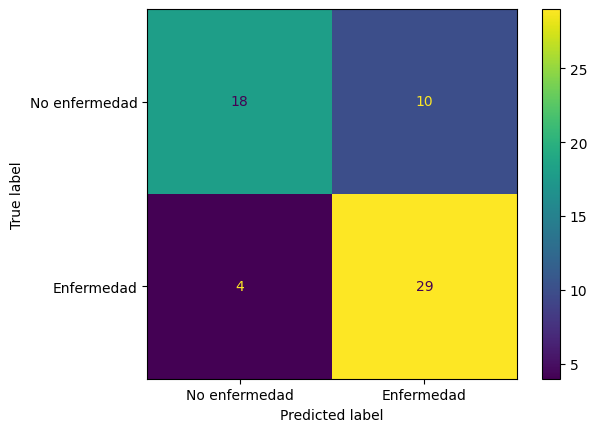

In [83]:
# Mostramos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No enfermedad', 'Enfermedad'])
disp.plot()
plt.show()

In [84]:
# Se puede hacer un recuento usando un método ya conocido
y_test.value_counts()

target
1    33
0    28
Name: count, dtype: int64

In [85]:
# Se puede hacer un recuento usando un método ya conocido
y_test.value_counts(normalize=True)

target
1    0.540984
0    0.459016
Name: proportion, dtype: float64

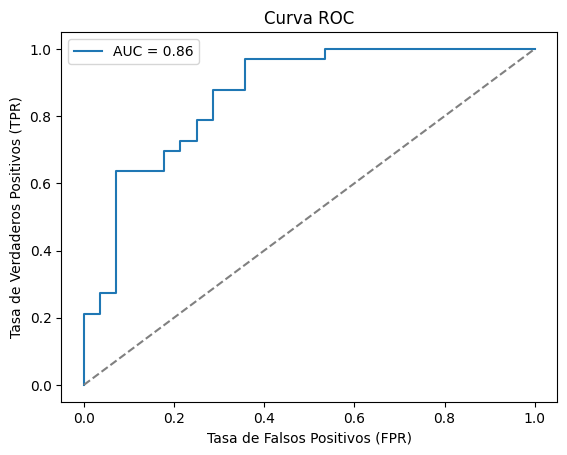

In [86]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [87]:
# Versión de Plotly de la curva ROC
fig = px.area(
    x=fpr,
    y=tpr,
    title=f'ROC Curve (AUC={auc:.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show(renderer='iframe')

## 3. Árboles de decisión
Son de los algoritmos más intuitivos y visuales. En este caso, estos algoritmos se pueden utilizar tanto para problemas de regresión (variables continuas) como de clasificación (predecir variables categóricas).

Las clases que utilizaremos serán `DecisionTreeClassifier` (clasificación) y `DecisionTreeRegressor` (regresión), además importaremos la función `plot_tree` que nos permitirá dibujar el árbol resultante:
```python
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
```

Algunos hiperparámetros interesantes:
| Hiperparámetro      | ¿Para qué sirve?                      | Valores típicos    |
| ------------------- | ------------------------------------- | ------------------ |
| max\_depth          | Profundidad máxima de cada árbol      | Ninguno, 5, 10, 20 |
| min\_samples\_split | Muestras mínimas para dividir un nodo | 2, 5, 10           |
| min\_samples\_leaf  | Muestras mínimas en una hoja          | 1, 2, 4            |

### 3.1 Árboles de decisión para clasificación

In [88]:
# Entrenamos un modelo de árbol de decisión
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [89]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

In [90]:
# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Enfermedad'
y_proba = modelo_dt.predict_proba(X_test)[:, 1]

In [91]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.75
Precisión: 0.75
Recall:    0.82
F1-Score:  0.78
AUC:       0.82



In [92]:
# Verificamos cuántos elementos hay predichos
len(y_pred)

61

In [93]:
X_heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [94]:
(X_train)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
19,69,0,3,140,239,0,1,151,0,1.8,2,2,2
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
289,55,0,0,128,205,0,2,130,1,2.0,1,1,3
288,57,1,0,110,335,0,1,143,1,3.0,1,1,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,65,0,2,160,360,0,0,151,0,0.8,2,0,2
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
140,51,0,2,120,295,0,0,157,0,0.6,2,0,2
114,55,1,1,130,262,0,1,155,0,0.0,2,0,2


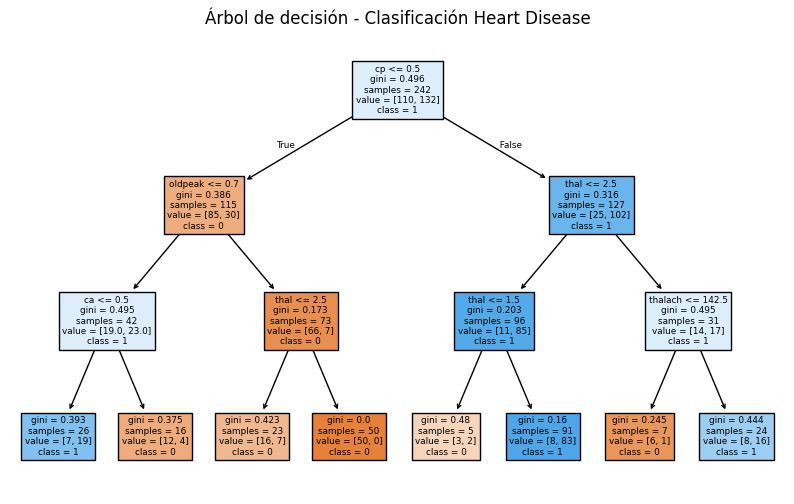

In [95]:
# Visualizamos el árbol
plt.figure(figsize=(10, 6))
plot_tree(modelo_dt, feature_names=X_heart.columns.to_list(), class_names=['0', '1'], filled=True)
plt.title("Árbol de decisión - Clasificación Heart Disease")
plt.show()

#### Aplica GridSearch para optimizar los hiperparámetros

Usa la siguiente matriz:
```python
dict_parametros = {
    'max_depth': [2, 3, 5, 10, 20, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
```

In [96]:
# Entrenamiento de un modelo de árbol de decisión con GridSearchCV para encontrar los mejores hiperparámetrosmodel_dt = DecisionTreeClassifier(random_state=42)


In [ ]:
# Vemos cuáles son los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_dt_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_dt_cv.best_score_:.2%}")

In [ ]:
modelo_dt_cv.best_params_

In [ ]:
# Entrenamos el modelo con los mejores hiperparámetros encontrados


In [ ]:
# Obtenemos de manera dinámica el índice de la clase enfermedad
enfermedad_idx = np.where(modelo_dt.classes_ == 1)[0][0]

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = 

y_proba = 

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_dt.predict_proba(X_test)[:, enfermedad_idx]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

In [ ]:
# Visualizamos el árbol
plt.figure(figsize=(10, 6))
plot_tree(modelo_dt, feature_names=X_heart.columns.to_list(), class_names=list_heart_target, filled=True)
plt.title("Árbol de decisión - Clasificación Heart Disease")
plt.show()

### 3.2 Árboles de decisión para regresión
Este tipo de algoritmos también pueden servir para inferir variables continuas, para ello utiliaremos el dataset de "Advertising" guardado en `./data/advertising.csv`. Este dataset contiene el gasto en inversión de publicidad para diversos medios como TV, radio o periódicos respecto a las ventas obtenidas.

####  Carga y preprocesamiento de datos

In [98]:
# Cargamos el dataset de advertising
df_adversiting = pd.read_csv(PATH_DATASET_ADVERTISING)

In [99]:
# Mostramos el dataframe
df_adversiting.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [100]:
df_adversiting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [101]:
df_adversiting.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [102]:
# Convertimos a minúsculas las columnas
df_adversiting.columns = df_adversiting.columns.str.lower()

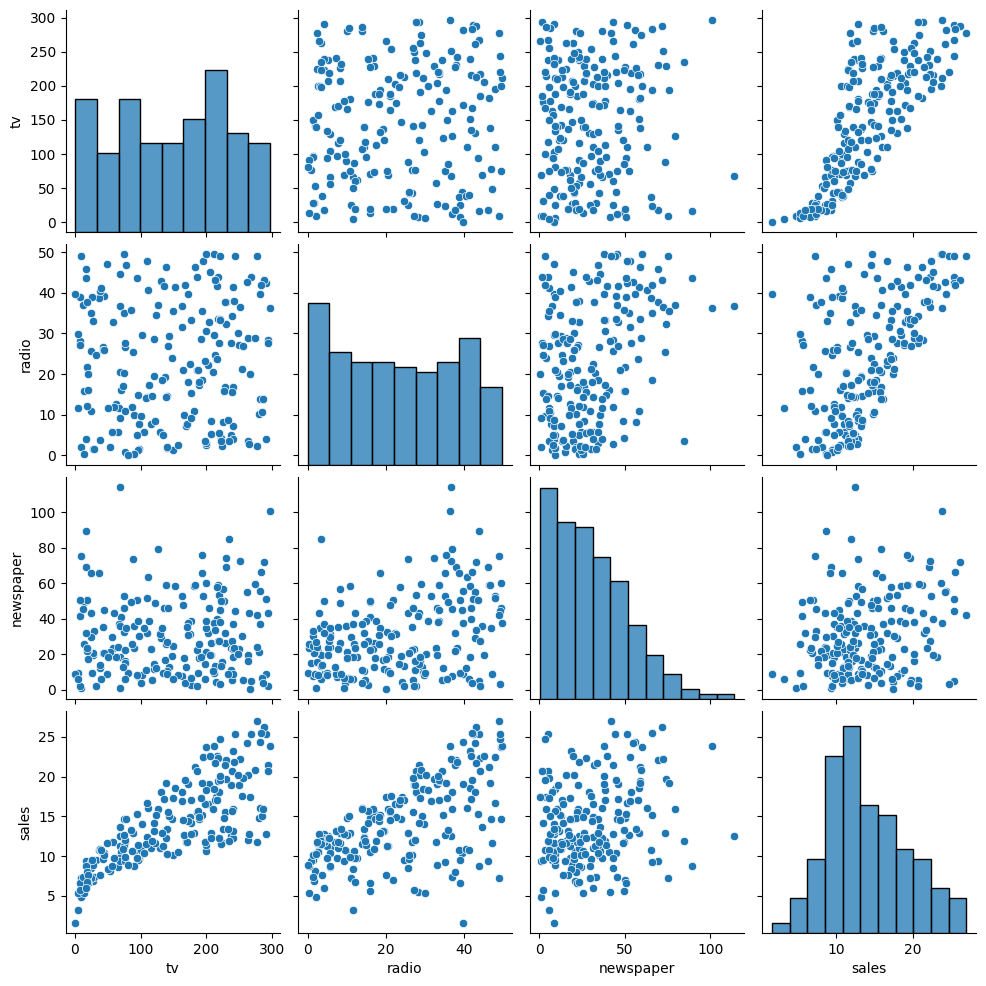

In [103]:
sns.pairplot(df_adversiting)

#### Modelo, ajuste y evaluación

In [104]:
# Mostramos la correlación entre algunas de sus variables
df_adversiting.drop(columns='sales').corr()

,tv,radio,newspaper
tv,1.000000,0.054809,0.056648
radio,0.054809,1.000000,0.354104
newspaper,0.056648,0.354104,1.000000


In [105]:
# Preparación de los datos para el modelo de regresión lineal
target_variable = 'sales'
X_ads = df_adversiting.drop(columns=target_variable)
y_ads = df_adversiting[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X_ads, y_ads, test_size=0.2, random_state=42) 

In [106]:
X_train

,tv,radio,newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6
...,...,...,...
106,25.0,11.0,29.7
14,204.1,32.9,46.0
92,217.7,33.5,59.0
179,165.6,10.0,17.6


In [107]:
y_train

79     11.0
197    12.8
38     10.1
24      9.7
122    11.6
       ... 
106     7.2
14     19.0
92     19.4
179    12.6
102    14.8
Name: sales, Length: 160, dtype: float64

In [108]:
# Entrenamiento del modelo de árbol de decisón de regresión
modelo_dtr = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [109]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dtr.predict(X_test)

# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 4.9566
RMSE (Raíz del error cuadrático medio): 2.2263
MAE (Error absoluto medio): 1.6856
R² (Coeficiente de determinación): 0.8430
El modelo explica aproximadamente el 84.30% de la varianza


#### Compararlo con un modelo de regresión lineal sencillo

In [110]:
# Entrenamos un modelo de regresion lineal simple
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)

# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 3.1741
RMSE (Raíz del error cuadrático medio): 1.7816
MAE (Error absoluto medio): 1.4608
R² (Coeficiente de determinación): 0.8994
El modelo explica aproximadamente el 89.94% de la varianza


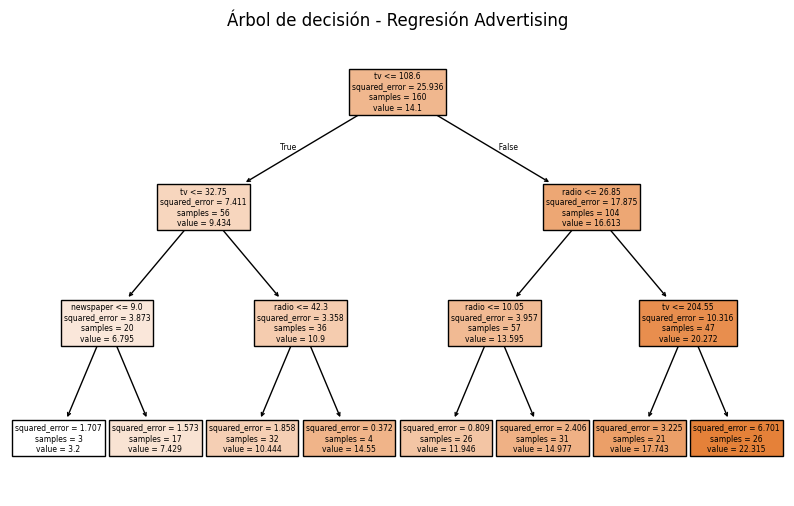

In [113]:
# Visualizamos el árbol
plt.figure(figsize=(10, 6))
plot_tree(modelo_dtr, feature_names=X_ads.columns.to_list(), filled=True)
plt.title("Árbol de decisión - Regresión Advertising")
plt.show()

## 4. Bosques aleatorios
Dado que un sólo árbol puede cometer errores así como tender a un sobreajuste, nace el concepto de entrenar muchos árboles a la vez y utilizar técnicas de *ensemble* y concretamente de *bagging* para poder combinar sus resultados y hacer más robusta la solución. Estos modelos se denominan "Random Forest" o Bosques Aleatorios.

Importaremos las siguientes clases:
```python
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
```

Algunos hiperparámetros interesantes:
| Hiperparámetro      | ¿Para qué sirve?                      | Valores típicos    |
| ------------------- | ------------------------------------- | ------------------ |
| n\_estimators       | Nº de árboles en el bosque            | 100, 200, 500      |
| max\_depth          | Profundidad máxima de cada árbol      | Ninguno, 5, 10, 20 |
| min\_samples\_split | Muestras mínimas para dividir un nodo | 2, 5, 10           |
| min\_samples\_leaf  | Muestras mínimas en una hoja          | 1, 2, 4            |


### 4.1 Bosques aleatorios para clasifiación

In [121]:
# Preparación de los datos para el entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# Entrenamiento de un modelo de RandomForest Classifier
modelo_rfc = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)
modelo_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=500, random_state=42)

In [122]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.87
Precisión: 0.85
Recall:    0.91
F1-Score:  0.88
AUC:       0.94



In [124]:
X_test.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [123]:
# Mostramos la importancia de las variables
modelo_rfc.feature_importances_

array([0.08639715, 0.03713001, 0.11162361, 0.07148522, 0.07438916,
       0.01077689, 0.01802669, 0.10961875, 0.07584393, 0.12447402,
       0.05112389, 0.13014093, 0.09896974])

In [131]:
# Importancia de variables
col_importancia_rf = modelo_rfc.feature_importances_

df_importances_rf = pd.DataFrame({
    'variable' : X_heart.columns,
    'importancia' : col_importancia_rf
})

In [132]:
df_importances_rf.sort_values(by=['importancia'], ascending=False)

,variable,importancia
11,ca,0.130141
9,oldpeak,0.124474
2,cp,0.111624
7,thalach,0.109619
12,thal,0.098970
0,age,0.086397
8,exang,0.075844
4,chol,0.074389
3,trestbps,0.071485
10,slope,0.051124


In [133]:
# Ordenamos el dataframe por la importancia de manera ascendente
df_importances_rf = df_importances_rf.sort_values(by='importancia', ascending=True)

In [135]:
# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_rf,
    x='importancia',
    y='variable',
    text='importancia',
    text_auto=".3%",
    title='Importancia de las variables en el modelo Random Forest',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=700, height=500
)
fig.update_layout(xaxis_tickangle=-45)
fig.show(renderer='iframe')

### 4.2 Bosques aleatorios para regresión

In [136]:
# Preparación de los datos para el modelo de bosque de regresión
X_train, X_test, y_train, y_test = train_test_split(X_ads, y_ads, test_size=0.2, random_state=42)

# Entrenamiento de un modelo de RandomForest Regressor
modelo_rfr = RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42)
modelo_rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, n_estimators=200, random_state=42)

In [137]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfr.predict(X_test)

# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 1.9234
RMSE (Raíz del error cuadrático medio): 1.3869
MAE (Error absoluto medio): 1.0687
R² (Coeficiente de determinación): 0.9391
El modelo explica aproximadamente el 93.91% de la varianza


In [138]:
# Importancia de variables
col_importancia_rf = modelo_rfr.feature_importances_

df_importances_rf = pd.DataFrame({
    'variable' : X_ads.columns,
    'importancia' : col_importancia_rf
})

In [139]:
df_importances_rf

,variable,importancia
0,tv,0.640308
1,radio,0.353996
2,newspaper,0.005696


## 5. XGBoost
XGBoost (eXtreme Gradient Boosting) es un modelo de Machine Learning basado en árboles de decisión pero utiliza otra técnica diferente de ensemble llamada *boosting* (de ahí su nombre). Esto le permite que los diferentes modelos se combinen mejorando de manera secuencial el error.

Además, algo destacable, XGBoost viene de otra librería diferente, no viene de `Sklearn`, sin embargo la sintaxis es prácticamente igual. Esto se conoce a que sigue la especificación de la API de `Sklearn`. Para importar XGBoost introducimos las siguientes líneas:
```python
from xgboost import XGBClassifier, XGBRegressor
```

Algunos hiperparámetros relevantes:
+ `n_estimators`: Número de árboles (rondas de boosting)
+ `max_depth`:  Profundidad máxima de cada árbol
+ `learning_rate`:  Cuánto aprende cada árbol nuevo
+ `eval_metric`:  Métrica de evaluación para clasificación, se puede utilizar `logloss` para clasificación binaria o `mlogloss` para multiclase / mutilabel.

### 5.1 XGBoost para clasificación

In [143]:
# Casteamos el sexo a tipo string
df_heart_preprocessed['sex'] = df_heart_preprocessed['sex'].astype(str)

In [145]:
df_heart_preprocessed

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [147]:
X_heart = df_heart_preprocessed.drop(columns=target_column)

In [149]:
X_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 30.9+ KB


In [150]:
X_heart['restecg'].value_counts()

restecg
1    152
0    147
2      4
Name: count, dtype: int64

In [151]:
X_heart.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1


In [152]:
# Convertimos las variables categóricas a variables dummy (one-hot encoding)
X_heart_encoded = pd.get_dummies(X_heart)

In [153]:
# Mostramos las primeras filas del DataFrame codificado
X_heart_encoded.head()

,age,trestbps,chol,fbs,thalach,exang,oldpeak,ca,sex_0,sex_1,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,63,145,233,1,150,0,2.3,0,False,True,...,True,False,False,True,False,False,False,True,False,False
1,37,130,250,0,187,0,3.5,0,False,True,...,False,True,False,True,False,False,False,False,True,False
2,41,130,204,0,172,0,1.4,0,True,False,...,True,False,False,False,False,True,False,False,True,False
3,56,120,236,0,178,0,0.8,0,False,True,...,False,True,False,False,False,True,False,False,True,False
4,57,120,354,0,163,1,0.6,0,True,False,...,False,True,False,False,False,True,False,False,True,False


In [165]:
# Preparación de los datos para el modelo de clasificación
X_train, X_test, y_train, y_test = train_test_split(X_heart_encoded, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

In [166]:
y_train.value_counts(normalize=True)

target
1    0.545455
0    0.454545
Name: proportion, dtype: float64

In [167]:
y_test.value_counts(normalize=True)

target
1    0.540984
0    0.459016
Name: proportion, dtype: float64

In [168]:
# Entrenamiento de un modelo de XGBoost Classifier
modelo_xgbc = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, eval_metric='logloss', random_state=42)
modelo_xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [159]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_xgbc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_xgbc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.82
Precisión: 0.86
Recall:    0.78
F1-Score:  0.82
AUC:       0.91



### 5.2 XGBoost para regresión

In [169]:
# Preparación de los datos para el modelo de regresión lineal
X_train, X_test, y_train, y_test = train_test_split(X_ads, y_ads, test_size=0.2)

# Entrenamiento de un modelo de RandomForest Regressor
modelo_xgbr = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1, random_state=42)
modelo_xgbr.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [170]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_xgbr.predict(X_test)

# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 1.2601
RMSE (Raíz del error cuadrático medio): 1.1226
MAE (Error absoluto medio): 0.6928
R² (Coeficiente de determinación): 0.9609
El modelo explica aproximadamente el 96.09% de la varianza


## 6. KNN
KNN es uno de los algoritmos más fáciles de entender en Machine Learning.

+ En clasificación: Cada nueva observación recibe la clase que sea más frecuente entre sus K vecinos más cercanos.
+ En regresión: Cada nueva observación recibe el valor medio de sus K vecinos.

Lo habitual es usar la distancia Euclídea (la distancia 'normal' en un espacio de varias dimensiones), pero se pueden usar otras. Importaremos estos algoritmos usando la siguiente línea:
```python
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
```

KNN es un algoritmo basado en distancias, entonces es clave que sus datos se escalen. En este caso utilizaremos la técnica de la estadarización, que lo que hará será transformar las métricas para que tengan media 0 y desviación típica 1. Para ello se importará la clase `StandardScaler`:

```python
from sklearn.preprocessing import StandardScaler
```

<center><img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_classification_001.png"  alt="KNN" width="700"/></center>

### 6.1 KNN para clasificación

In [126]:
# Preparación de los datos para el entrenamiento del modelo


# Entrenamiento de un modelo de KNN Classifier



KNeighborsClassifier()

In [127]:
# Hacemos predicciones sobre el conjunto de test


# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_knnc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.59
Precisión: 0.62
Recall:    0.61
F1-Score:  0.62
AUC:       0.64



In [128]:
# Escalamos los datos de los conjuntos de entrenamiento y prueba
# Esto es importante para los modelos basados en distancias como KNN y SVM




In [129]:
# Mostramos las estadísticas descriptivas de los datos de entrenamiento


,count,mean,std,min,25%,50%,75%,max
age,242.0,54.289256,9.153317,29.0,47.00,55.5,61.00,77.0
trestbps,242.0,131.706612,17.994486,94.0,120.00,130.0,140.00,200.0
chol,242.0,244.884298,47.847387,126.0,211.25,240.0,273.75,409.0
fbs,242.0,0.140496,0.348221,0.0,0.00,0.0,0.00,1.0
thalach,242.0,150.123967,21.977948,88.0,137.25,152.0,166.00,202.0
exang,242.0,0.338843,0.474297,0.0,0.00,0.0,1.00,1.0
oldpeak,242.0,1.071901,1.206258,0.0,0.00,0.8,1.80,6.2
ca,242.0,0.743802,1.042889,0.0,0.00,0.0,1.00,4.0


In [130]:
# Descripción estadística de los datos escalados


,count,mean,std,min,25%,50%,75%,max
age,242.0,3.523352e-16,1.002073,-2.768578,-0.798002,0.132548,0.734668,2.486291
trestbps,242.0,2.642514e-16,1.002073,-2.099797,-0.651915,-0.095037,0.461840,3.803105
chol,242.0,-1.541467e-16,1.002073,-2.489806,-0.704406,-0.102292,0.604537,3.437091
fbs,242.0,-3.670159e-17,1.002073,-0.404304,-0.404304,-0.404304,-0.404304,2.473388
thalach,242.0,-3.963771e-16,1.002073,-2.832508,-0.586981,0.085537,0.723859,2.365259
exang,242.0,1.211152e-16,1.002073,-0.715891,-0.715891,-0.715891,1.396861,1.396861
oldpeak,242.0,1.481827e-16,1.002073,-0.890458,-0.890458,-0.225876,0.604853,4.260057
ca,242.0,2.202095e-17,1.002073,-0.714691,-0.714691,-0.714691,0.246171,3.128758


In [131]:
# Entrenamiento de un modelo de KNN Classifier con los datos escalados



KNeighborsClassifier()

In [132]:
# Hacemos predicciones sobre el conjunto de test


# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_knnc.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.77
Precisión: 0.74
Recall:    0.88
F1-Score:  0.81
AUC:       0.81



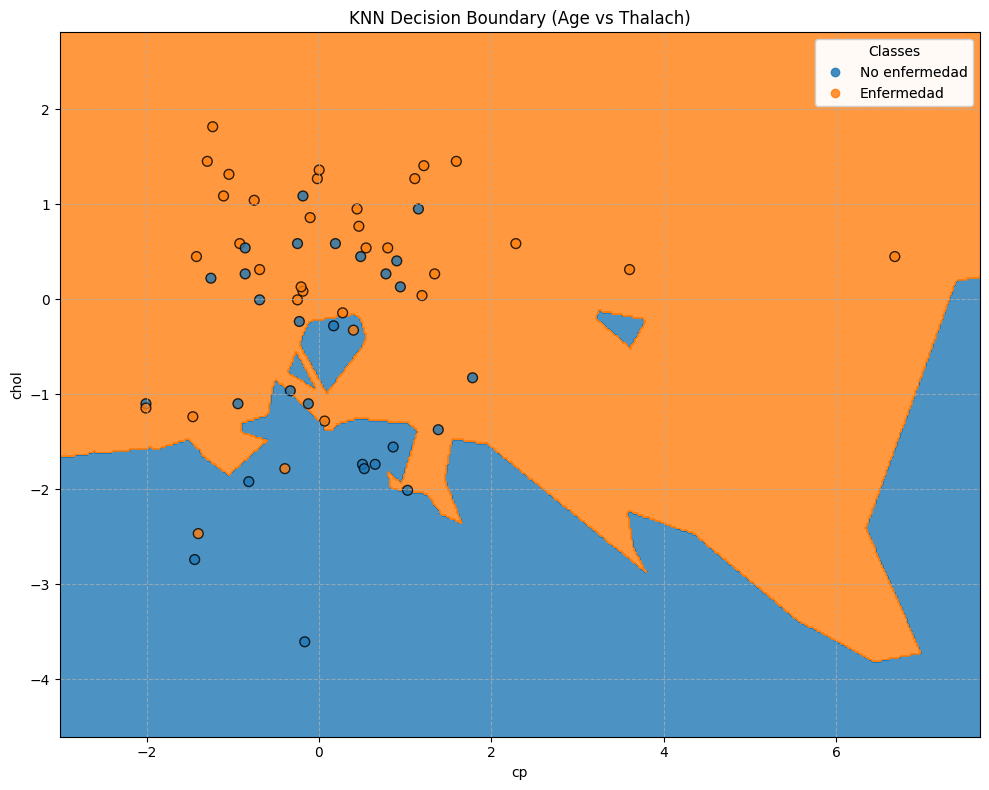

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'KNN Decision Boundary (Age vs Thalach)'}, xlabel='cp', ylabel='chol'>)

In [133]:
plot_knn_decision_boundary(
    model=modelo_knnc,
    X=pd.DataFrame(X_test_scaled, columns=X_train.columns),
    y=y_test,
    feature1_idx='chol',
    feature2_idx='thalach',
    feature_names=X_heart.columns,
    class_names=['No enfermedad', 'Enfermedad'],
    plot_title="KNN Decision Boundary (Age vs Thalach)"
)

### 6.2 KNN para regresión

In [134]:
# Preparación de los datos para el modelo de regresión


# Escalamos los datos de los conjuntos de entrenamiento y prueba
# Esto es importante para los modelos basados en distancias como KNN y SVM



# Entrenamiento de un modelo de KNN Regressor con los datos escalados



KNeighborsRegressor()

In [135]:
# Hacemos predicciones sobre el conjunto de test


# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 2.2074
RMSE (Raíz del error cuadrático medio): 1.4857
MAE (Error absoluto medio): 1.0895
R² (Coeficiente de determinación): 0.9301
El modelo explica aproximadamente el 93.01% de la varianza


## 7. Support Vector Machines (SVM)

Su objetivo es encontrar la frontera (hiperplano) que mejor separa las clases (en clasificación) o aproximar una función (en regresión).

+ Clasificación: Busca la línea, plano o hiperplano que separa las clases dejando el mayor margen posible entre ellas.
+ Regresión (SVR): Busca una línea o superficie que ajuste los datos, permitiendo que algunos puntos se queden dentro de una banda de tolerancia.

Importamos ambos algoritmos usando la siguiente línea:
```python
from sklearn.svm import SVC, SVR
```

Algunos hiperparámetros interesantes:

| Hiperparámetro | ¿Para qué sirve?                           | Valores comunes          |
| -------------- | ------------------------------------------ | ------------------------ |
| C              | Regulariza el margen y tolerancia al error | 0.1, 1, 10, 100          |
| kernel         | Forma de la frontera de decisión           | 'linear', 'rbf', 'poly'  |


### 7.1 SVM para clasificación

In [136]:
# Preparación de los datos para el entrenamiento del modelo
# Filtrar sólo por aquellos valores numéricos usando .select_dtypes()


# Escalamos los datos de los conjuntos de entrenamiento y prueba
# Esto es importante para los modelos basados en distancias como KNN y SVM



# Entrenamiento de un modelo de SVM Classifier con los datos escalados
# Añadimos el hiperparámetro probability=True para poder obtener las probabilidades de pertenencia a cada clase
# Ya que no funciona igual que el resto de algoritmos y no lo activa por defecto



SVC(probability=True, random_state=42)

In [137]:
# Hacemos predicciones sobre el conjunto de test


# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_svc.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.79
Precisión: 0.76
Recall:    0.88
F1-Score:  0.82
AUC:       0.84



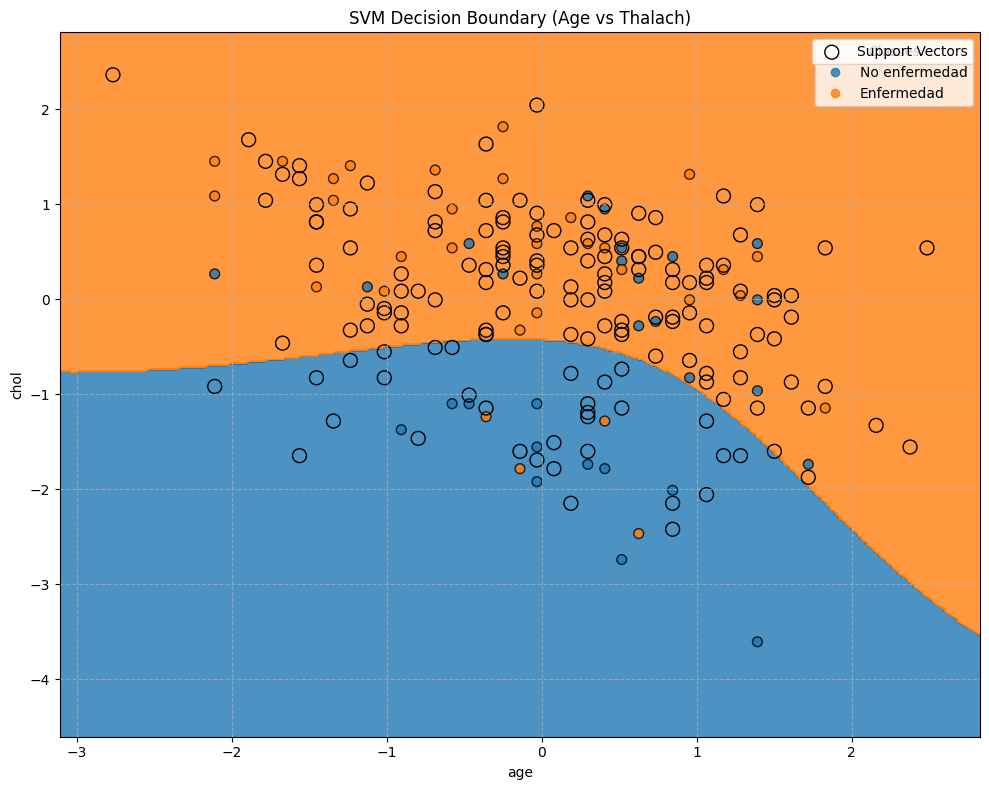

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'SVM Decision Boundary (Age vs Thalach)'}, xlabel='age', ylabel='chol'>)

In [138]:
plot_svc_decision_boundary(
    model=modelo_svc,
    X=pd.DataFrame(X_test_scaled, columns=X_train.columns),
    y=y_test,
    feature1_idx='age',
    feature2_idx='thalach',
    feature_names=X_heart.columns,
    class_names=['No enfermedad', 'Enfermedad'],
    plot_title="SVM Decision Boundary (Age vs Thalach)"
)

### 7.2 SVR para regresión

In [139]:
# Preparación de los datos para el modelo de regresión


# Escalamos los datos de los conjuntos de entrenamiento y prueba
# Esto es importante para los modelos basados en distancias como KNN y SVM



# Entrenamiento de un modelo de RandomForest Regressor



SVR(C=0.8)

In [140]:
# Hacemos predicciones sobre el conjunto de test


# Evaluamos el modelo usando las métricas de regresión
mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)


Evaluación del modelo:
MSE (Error cuadrático medio): 3.6550
RMSE (Raíz del error cuadrático medio): 1.9118
MAE (Error absoluto medio): 1.3506
R² (Coeficiente de determinación): 0.8842
El modelo explica aproximadamente el 88.42% de la varianza


## 99. Ejercicios modelos supervisados
Para los ejercicios utilizad:
+ Ejercicios de clasificación: dataset de "Breast Cancer", que se importará del mismo modo que hicimos con iris desde `sklearn` usando `load_breast_cancer()`. ⚠️ No está importado el módulo, búscalo e impórtalo.
+ Ejercicios de regresión: dataset de `housing_boston.csv`, que ya hemos utilizado en la clase 1.

### 1. Crea una regresión logística utilizando el dataframe de "Breast Cancer"

In [113]:
from sklearn.datasets import load_breast_cancer

In [110]:
# Cargamos el dataset de cáncer de mama
data_breast_cancer = load_breast_cancer(as_frame=True, return_X_y=False)

### 2. Genera un modelo de KNN y de SVR para regresión
Utiliza el dataset de "Advertising" y compara el rendimiento de ambos modelos

In [124]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

### 3. Utiliza GridSearch para optimizar los hiperparámetros de XGBoost
Tomando de nuevo el dataset de "Breast Cancer", usa XGBoost para encontrar la mejor combinación de hiperparámetros que maximicen la precisión. A continuación la documentación que te ayudará a escoger el buen `scoring`: [Scikit-learn - 3.4. Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers)

#### Modelo baseline XGBoost
Entrenamos un modelo baseline para comparar el performance contra el optimizado

#### Modelo con optimización de hiperparámetros
Usamos GridSearch para encontrar los mejores hiperparámetros que mejoren el performance del modelo base

### 4. Encuentra cuál es el mejor algoritmo para resolver un problema de regresión
Utilizando el dataset de "Boston Prices", encuentra cuál es el mejor algoritmo para predecir el precio de la vivienda entre los que hemos estudiado: regresión lineal, árboles de decisión, bosques aleatorios, XGBoost.

In [187]:
# Cargamos el dataset de Boston
df_boston = pd.read_csv(PATH_DATASET_BOSTON)

#### Regresión Lineal

In [ ]:
# Entrenamos un modelo de regresión lineal
modelo_boston = LinearRegression()
modelo_boston.fit(X, y)

### 5. Modelos con LightGBM
LightGBM es otro algoritmo de Gradient Boosting muy similar a XGBoost, incluso a nivel de performance y rapidez puede llegar a ser más rápido en ciertos casos. Dado que su sintaxis es muy similar, investigar (es algo fácil 🙂) para utilizar su librería `lightgbm` para entrenar tanto un modelo de clasificación como de regresión con los ejemplos vistos en el apartado 5 de XGBoost y comparar el performance de ambos enfoques.

💡 En el apartado superior se encuentran algunos links relevantes.

In [176]:
from lightgbm import LGBMClassifier, LGBMRegressor

#### LightGBM para clasificación

In [ ]:
# Preparación de los datos para el modelo de clasificación
X_train, X_test, y_train, y_test = train_test_split(X_heart_encoded, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

#### LightGBM para regresión

In [180]:
# Preparación de los datos para el modelo de regresión lineal
X_train, X_test, y_train, y_test = train_test_split(X_ads, y_ads, test_size=0.2, random_state=42)